In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip install transformers
!pip install -U gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 93.5 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import numpy as np
import random
import os

SEED = 2025

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

In [ ]:
import tensorflow as tf

print("GPU available:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        print(e)

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
1 Physical GPUs, 1 Logical GPUs


In [ ]:
import tensorflow as tf

dataset_train = tf.data.Dataset.load("/content/drive/MyDrive/Universidad/Investigacion/tf_datasets/train")

In [ ]:
from tensorflow.keras.layers import Dense, Input, Dropout, Bidirectional, LSTM, Embedding, BatchNormalization, Reshape, Conv2D, MaxPool2D, concatenate, Flatten
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, MaxPooling1D, Input, Bidirectional, GRU, Flatten, concatenate, BatchNormalization, Dense, LeakyReLU, Activation
from tensorflow.keras.models import Model
from keras import regularizers

num_classes = 8

def create_input_branch(input_shape, name):
    input_layer = Input(shape=input_shape, name=name)
    dense1 = Dense(10000)(input_layer)
    batch1 = BatchNormalization()(dense1)
    activation1 = Activation('relu')(batch1)
    drop1 = Dropout(0.5)(activation1)

    dense2 = Dense(1000)(drop1)
    batch2 = BatchNormalization()(dense2)
    activation2 = Activation('relu')(batch2)
    drop2 = Dropout(0.2)(activation2)

    dense3 = Dense(10000)(drop2)
    batch3 = BatchNormalization()(dense3)
    activation3 = Activation('relu')(batch3)
    drop3 = Dropout(0.2)(activation3)
    return input_layer, drop3

input_nl, output_nl = create_input_branch((768,), "nl")
input_pl, output_pl = create_input_branch((768,), "pl")
input_initial, output_initial = create_input_branch((768,), "initial")
input_transformation, output_transformation = create_input_branch((768,), "transformation")
input_js, output_js = create_input_branch((768,), "js")
input_final, output_final = create_input_branch((768,), "final")


concat = concatenate([output_nl, output_pl, output_initial, output_transformation, output_js, output_final])

output = Dense(num_classes)(concat)
output = BatchNormalization()(output)
output = Activation('softmax')(output)

model = Model(inputs=[input_nl, input_pl, input_initial, input_transformation, input_js, input_final], outputs=output)

In [ ]:
%%time
from tensorflow.keras.optimizers import Adam
adam = Adam(learning_rate=0.00001)

model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy', tf.keras.metrics.F1Score(average='macro')])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ nl (InputLayer)     │ (None, 768)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pl (InputLayer)     │ (None, 768)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial             │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformation      │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ js (InputLayer)     │ (None, 768)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final (InputLayer)  │ (None, 768)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10000)     │  7,690,000 │ nl[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10000)     │  7,690,000 │ pl[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 10000)     │  7,690,000 │ initial[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 10000)     │  7,690,000 │ transformation[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 10000)     │  7,690,000 │ js[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 10000)     │  7,690,000 │ final[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10000)     │     40,000 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10000)     │     40,000 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10000)     │     40,000 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10000)     │     40,000 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10000)     │     40,000 │ dense_12[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10000)     │     40,000 │ dense_15[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 10000)     │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 10000)     │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 167,190,040 (637.78 MB)

 Trainable params: 166,938,024 (636.82 MB)

 Non-trainable params: 252,016 (984.44 KB)

CPU times: user 81 ms, sys: 2.59 ms, total: 83.6 ms
Wall time: 85.4 ms


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

total_size = dataset_train.reduce(0, lambda x, _: x + 1).numpy()
val_size = int(0.2 * total_size)

dataset_train = dataset_train.shuffle(
    buffer_size=total_size,
    seed=SEED,
    reshuffle_each_iteration=False
)

val_dataset = dataset_train.take(val_size)
train_dataset = dataset_train.skip(val_size)



epochs=150

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)


history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stop]
)

Epoch 1/150
991/991 ━━━━━━━━━━━━━━━━━━━━ 132s 117ms/step - accuracy: 0.3256 - f1_score: 0.3231 - loss: 1.7471 - val_accuracy: 0.5727 - val_f1_score: 0.5681 - val_loss: 1.2372
Epoch 2/150
991/991 ━━━━━━━━━━━━━━━━━━━━ 116s 116ms/step - accuracy: 0.5630 - f1_score: 0.5606 - loss: 1.3100 - val_accuracy: 0.7128 - val_f1_score: 0.7088 - val_loss: 1.0574
Epoch 3/150
991/991 ━━━━━━━━━━━━━━━━━━━━ 115s 116ms/step - accuracy: 0.6838 - f1_score: 0.6826 - loss: 1.1690 - val_accuracy: 0.7823 - val_f1_score: 0.7791 - val_loss: 0.9622
Epoch 4/150
991/991 ━━━━━━━━━━━━━━━━━━━━ 116s 116ms/step - accuracy: 0.7483 - f1_score: 0.7471 - loss: 1.0975 - val_accuracy: 0.8010 - val_f1_score: 0.7988 - val_loss: 0.9159
Epoch 5/150
991/991 ━━━━━━━━━━━━━━━━━━━━ 115s 116ms/step - accuracy: 0.7850 - f1_score: 0.7838 - loss: 1.0515 - val_accuracy: 0.8159 - val_f1_score: 0.8142 - val_loss: 0.8833
Epoch 6/150
991/991 ━━━━━━━━━━━━━━━━━━━━ 116s 116ms/step - accuracy: 0.8080 - f1_score: 0.8071 - loss: 1.0170 - val_accuracy:

In [ ]:
model.save('/content/drive/MyDrive/Universidad/Investigacion/models/1.keras')

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_f1 = history.history['f1_score']
val_f1 = history.history['val_f1_score']

In [ ]:
length = len(history.history['accuracy'])

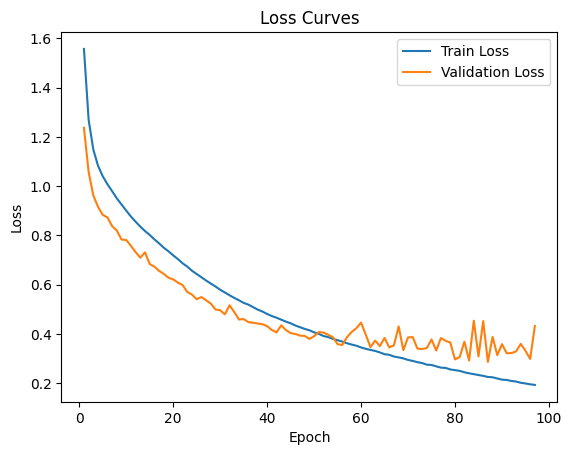

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, length+1), train_loss, label='Train Loss')
plt.plot(range(1, length+1), val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

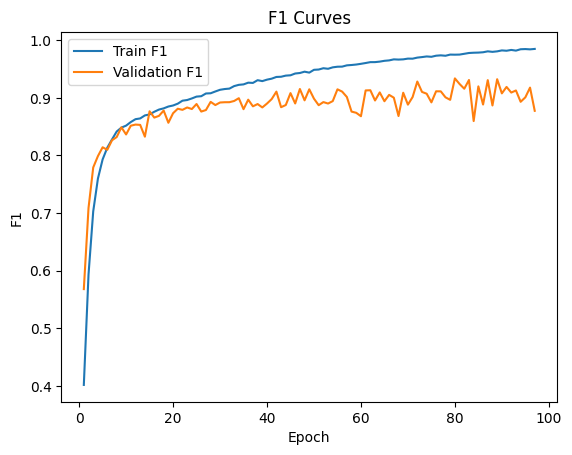

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, length+1), train_f1, label='Train F1')
plt.plot(range(1, length+1), val_f1, label='Validation F1')
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.title('F1 Curves')
plt.legend()
plt.show()